# Deep Supervision Ablation Study
## U-Net++ Deep Supervision 유무에 따른 성능 비교

**실험 목표**
- Deep Supervision 적용 시 학습 속도가 얼마나 빨라지는가?
- Deep Supervision 적용 시 경계선(Boundary) 표현이 얼마나 정교해지는가?

**비교 모델**
- Model A: U-Net (baseline)
- Model B: U-Net++ without Deep Supervision
- Model C: U-Net++ with Deep Supervision


In [1]:
# ========================================
# Step 0. WandB API 키 설정
# ========================================
import os
os.environ["WANDB_API_KEY"] = "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"

import wandb
print("WandB 설정 완료")

WandB 설정 완료


In [2]:
# ========================================
# Step 1. 라이브러리 임포트
# ========================================
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from glob import glob
from skimage.io import imread
from skimage.transform import resize
from torch.utils.data import Dataset, DataLoader
from albumentations import HorizontalFlip, RandomSizedCrop, Compose, Resize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


In [3]:
# ========================================
# Seed 고정 (재현성 보장)
# ========================================
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # 완전한 재현성 보장 (속도 약간 저하될 수 있음)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seed 42 고정 완료")

Seed 42 고정 완료


In [4]:
# ========================================
# Step 2. 데이터셋 준비
# ========================================
def build_augmentation(is_train=True):
    if is_train:
        return Compose([
            HorizontalFlip(p=0.5),
            RandomSizedCrop(
                min_max_height=(300, 370),
                w2h_ratio=370/1242,
                height=224, width=224,
                size=(224, 224), p=0.5
            ),
            Resize(width=224, height=224)
        ])
    return Compose([Resize(width=224, height=224)])


class KittiDataset(Dataset):
    def __init__(self, dir_path, is_train=True, augmentation=None):
        self.dir_path     = dir_path
        self.augmentation = augmentation
        self.data         = self._load(is_train)

    def _load(self, is_train):
        inputs = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        labels = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))
        data   = list(zip(inputs, labels))
        return data[:-30] if is_train else data[-30:]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, lbl_path = self.data[idx]
        img = imread(img_path)
        lbl = (imread(lbl_path) == 7).astype(np.uint8)

        if self.augmentation:
            aug = self.augmentation(image=img, mask=lbl)
            img = aug["image"] / 255.0
            lbl = aug["mask"]

        lbl = np.expand_dims(lbl, axis=0)
        return (
            torch.tensor(img, dtype=torch.float32).permute(2, 0, 1),
            torch.tensor(lbl, dtype=torch.float32)
        )


data_dir     = os.path.join(os.getenv("HOME"), "work/semantic_segmentation/data/training")
train_dataset = KittiDataset(data_dir, is_train=True,  augmentation=build_augmentation(True))
test_dataset  = KittiDataset(data_dir, is_train=False, augmentation=build_augmentation(False))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False)

print(f"학습: {len(train_dataset)}장 / 테스트: {len(test_dataset)}장")

학습: 170장 / 테스트: 30장


/tmp/ipykernel_409/1957360909.py:8: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(


In [5]:
# ========================================
# Step 3-A. U-Net 모델 (Baseline)
# ========================================
class UNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super().__init__()
        self.enc1 = self.dconv(input_channels, 64)
        self.enc2 = self.dconv(64,  128)
        self.enc3 = self.dconv(128, 256)
        self.enc4 = self.dconv(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = self.dconv(512, 1024)
        self.dropout    = nn.Dropout(0.5)
        self.up6  = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec6 = self.dconv(1024, 512)
        self.up7  = nn.ConvTranspose2d(512,  256, 2, 2)
        self.dec7 = self.dconv(512,  256)
        self.up8  = nn.ConvTranspose2d(256,  128, 2, 2)
        self.dec8 = self.dconv(256,  128)
        self.up9  = nn.ConvTranspose2d(128,   64, 2, 2)
        self.dec9 = self.dconv(128,   64)
        self.final = nn.Conv2d(64, output_channels, 1)

    def dconv(self, i, o):
        return nn.Sequential(
            nn.Conv2d(i, o, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(o, o, 3, padding=1), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        c1 = self.enc1(x);          p1 = self.pool(c1)
        c2 = self.enc2(p1);         p2 = self.pool(c2)
        c3 = self.enc3(p2);         p3 = self.pool(c3)
        c4 = self.enc4(p3);         p4 = self.pool(c4)
        c5 = self.dropout(self.bottleneck(p4))
        u6 = self.dec6(torch.cat([self.up6(c5), c4], dim=1))
        u7 = self.dec7(torch.cat([self.up7(u6), c3], dim=1))
        u8 = self.dec8(torch.cat([self.up8(u7), c2], dim=1))
        u9 = self.dec9(torch.cat([self.up9(u8), c1], dim=1))
        return torch.sigmoid(self.final(u9))

print("U-Net 정의 완료")

U-Net 정의 완료


In [6]:
# ========================================
# Step 3-B. U-Net++ 모델
#
# deep_supervision=True  → 4개 출력 모두 Loss 계산 (DS 있음)
# deep_supervision=False → 마지막 출력만 Loss 계산 (DS 없음)
#
# 논문 수식:
#   x^{i,j} = H( [x^{i,0}...x^{i,j-1}], U(x^{i+1,j-1}) )
#   H = double conv, U = ConvTranspose2d, [] = concat
# ========================================
class UNetPlusPlus(nn.Module):
    def __init__(self, input_channels=3, output_channels=1,
                 deep_supervision=True):
        super().__init__()
        self.deep_supervision = deep_supervision

        nb = [64, 128, 256, 512, 1024]

        # Encoder
        self.enc0_0 = self.dconv(input_channels, nb[0])
        self.enc1_0 = self.dconv(nb[0], nb[1])
        self.enc2_0 = self.dconv(nb[1], nb[2])
        self.enc3_0 = self.dconv(nb[2], nb[3])
        self.enc4_0 = self.dconv(nb[3], nb[4])
        self.pool    = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.5)

        # 스킵 경로 노드
        self.enc0_1 = self.dconv(nb[0] + nb[1],    nb[0])
        self.enc1_1 = self.dconv(nb[1] + nb[2],    nb[1])
        self.enc2_1 = self.dconv(nb[2] + nb[3],    nb[2])
        self.enc3_1 = self.dconv(nb[3] + nb[4],    nb[3])

        self.enc0_2 = self.dconv(nb[0]*2 + nb[1],  nb[0])
        self.enc1_2 = self.dconv(nb[1]*2 + nb[2],  nb[1])
        self.enc2_2 = self.dconv(nb[2]*2 + nb[3],  nb[2])

        self.enc0_3 = self.dconv(nb[0]*3 + nb[1],  nb[0])
        self.enc1_3 = self.dconv(nb[1]*3 + nb[2],  nb[1])

        self.enc0_4 = self.dconv(nb[0]*4 + nb[1],  nb[0])

        # 업샘플링 레이어 (출력 채널 = 입력과 동일 유지)
        self.up1_0 = nn.ConvTranspose2d(nb[1], nb[1], 2, 2)
        self.up2_0 = nn.ConvTranspose2d(nb[2], nb[2], 2, 2)
        self.up3_0 = nn.ConvTranspose2d(nb[3], nb[3], 2, 2)
        self.up4_0 = nn.ConvTranspose2d(nb[4], nb[4], 2, 2)

        self.up1_1 = nn.ConvTranspose2d(nb[1], nb[1], 2, 2)
        self.up2_1 = nn.ConvTranspose2d(nb[2], nb[2], 2, 2)
        self.up3_1 = nn.ConvTranspose2d(nb[3], nb[3], 2, 2)

        self.up1_2 = nn.ConvTranspose2d(nb[1], nb[1], 2, 2)
        self.up2_2 = nn.ConvTranspose2d(nb[2], nb[2], 2, 2)

        self.up1_3 = nn.ConvTranspose2d(nb[1], nb[1], 2, 2)

        # 출력 레이어 (DS: 4개 / no DS: 1개)
        self.final1 = nn.Conv2d(nb[0], output_channels, 1)
        self.final2 = nn.Conv2d(nb[0], output_channels, 1)
        self.final3 = nn.Conv2d(nb[0], output_channels, 1)
        self.final4 = nn.Conv2d(nb[0], output_channels, 1)

    def dconv(self, i, o):
        return nn.Sequential(
            nn.Conv2d(i, o, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(o, o, 3, padding=1), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # j=0: 인코더
        x0_0 = self.enc0_0(x)
        x1_0 = self.enc1_0(self.pool(x0_0))
        x2_0 = self.enc2_0(self.pool(x1_0))
        x3_0 = self.enc3_0(self.pool(x2_0))
        x4_0 = self.dropout(self.enc4_0(self.pool(x3_0)))

        # j=1
        x0_1 = self.enc0_1(torch.cat([x0_0, self.up1_0(x1_0)], dim=1))
        x1_1 = self.enc1_1(torch.cat([x1_0, self.up2_0(x2_0)], dim=1))
        x2_1 = self.enc2_1(torch.cat([x2_0, self.up3_0(x3_0)], dim=1))
        x3_1 = self.enc3_1(torch.cat([x3_0, self.up4_0(x4_0)], dim=1))

        # j=2
        x0_2 = self.enc0_2(torch.cat([x0_0, x0_1, self.up1_1(x1_1)], dim=1))
        x1_2 = self.enc1_2(torch.cat([x1_0, x1_1, self.up2_1(x2_1)], dim=1))
        x2_2 = self.enc2_2(torch.cat([x2_0, x2_1, self.up3_1(x3_1)], dim=1))

        # j=3
        x0_3 = self.enc0_3(torch.cat([x0_0, x0_1, x0_2, self.up1_2(x1_2)], dim=1))
        x1_3 = self.enc1_3(torch.cat([x1_0, x1_1, x1_2, self.up2_2(x2_2)], dim=1))

        # j=4
        x0_4 = self.enc0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up1_3(x1_3)], dim=1))

        out1 = torch.sigmoid(self.final1(x0_1))
        out2 = torch.sigmoid(self.final2(x0_2))
        out3 = torch.sigmoid(self.final3(x0_3))
        out4 = torch.sigmoid(self.final4(x0_4))

        if self.training:
            if self.deep_supervision:
                return out1, out2, out3, out4  # DS 있음: 4개 반환
            else:
                return (out4,)                 # DS 없음: 마지막만
        if self.deep_supervision:
            return (out1 + out2 + out3 + out4) / 4
        return out4

print("U-Net++ 정의 완료 (deep_supervision 옵션 포함)")

U-Net++ 정의 완료 (deep_supervision 옵션 포함)


In [7]:
# ========================================
# Step 4. Loss 함수
# ========================================
def dice_loss(pred, target, smooth=1e-7):
    pred   = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)
    inter  = (pred * target).sum()
    return 1 - (2. * inter + smooth) / (pred.sum() + target.sum() + smooth)

def bce_dice_loss(pred, target):
    return F.binary_cross_entropy(pred, target) + dice_loss(pred, target)

def unetpp_loss(outputs, target):
    """DS 출력 개수에 관계없이 평균 Loss 계산"""
    return sum(bce_dice_loss(o, target) for o in outputs) / len(outputs)

def calculate_iou(target, prediction):
    inter = np.logical_and(target, prediction).sum()
    union = np.logical_or(target,  prediction).sum()
    return inter / (union + 1e-7)

print("Loss 함수 정의 완료")

Loss 함수 정의 완료


In [8]:
# ========================================
# Step 5. WandB 포함 학습 함수
#
# 10 에폭마다 테스트셋 IoU 측정 후
# Loss + IoU 를 WandB에 실시간 기록
# ========================================
def train_with_wandb(model, model_name, train_loader, test_loader,
                     num_epochs=100, lr=1e-4):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    save_path = f"./work/semantic_segmentation/{model_name}.pth"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # WandB 실험 초기화
    wandb.init(
        project="unet-ablation-ds",
        name=model_name,
        config={
            "model":      model_name,
            "epochs":     num_epochs,
            "lr":         lr,
            "batch_size": train_loader.batch_size,
            "deep_supervision": getattr(model, "deep_supervision", "N/A"),
        },
        reinit=True
    )

    loss_history = []
    iou_history  = []

    for epoch in range(num_epochs):
        # ── 학습 ──
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            inputs  = inputs.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = unetpp_loss(outputs if isinstance(outputs, tuple) else (outputs,),
                               targets.float())
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)

        # ── 10 에폭마다 IoU 측정 ──
        if (epoch + 1) % 10 == 0:
            model.eval()
            iou_scores = []
            with torch.no_grad():
                for inputs, targets in test_loader:
                    inputs  = inputs.to(device)
                    outputs = model(inputs)
                    preds   = (outputs.cpu().numpy() > 0.5).astype(np.uint8)
                    tgts    = targets.numpy().astype(np.uint8)
                    for p, t in zip(preds, tgts):
                        iou_scores.append(calculate_iou(t, p))

            mean_iou = np.mean(iou_scores)
            iou_history.append(mean_iou)

            # WandB 로깅
            wandb.log({
                "epoch":    epoch + 1,
                "loss":     avg_loss,
                "mean_iou": mean_iou,
            })
            print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} "
                  f"| Loss: {avg_loss:.4f} | IoU: {mean_iou:.4f}")
        else:
            wandb.log({"epoch": epoch + 1, "loss": avg_loss})

    torch.save(model.state_dict(), save_path)
    wandb.finish()
    print(f"저장 완료: {save_path}")
    return loss_history, iou_history

print("학습 함수 정의 완료")

학습 함수 정의 완료


In [9]:
# ========================================
# Step 6-A. Model A: U-Net (Baseline) 학습
# ========================================
print("=" * 50)
print("Model A: U-Net 학습 시작")
print("=" * 50)

model_a = UNet(input_channels=3, output_channels=1)
loss_a, iou_a = train_with_wandb(
    model_a, "A_UNet",
    train_loader, test_loader,
    num_epochs=100, lr=1e-4
)

Model A: U-Net 학습 시작


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: cbh8483 (cbh8483-snh-tech) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[A_UNet] Epoch 10/100 | Loss: 0.4214 | IoU: 0.6991
[A_UNet] Epoch 20/100 | Loss: 0.4077 | IoU: 0.6889
[A_UNet] Epoch 30/100 | Loss: 0.3478 | IoU: 0.7769
[A_UNet] Epoch 40/100 | Loss: 0.3217 | IoU: 0.6770
[A_UNet] Epoch 50/100 | Loss: 0.2915 | IoU: 0.7242
[A_UNet] Epoch 60/100 | Loss: 0.2791 | IoU: 0.6958
[A_UNet] Epoch 70/100 | Loss: 0.2431 | IoU: 0.7395
[A_UNet] Epoch 80/100 | Loss: 0.2409 | IoU: 0.7777
[A_UNet] Epoch 90/100 | Loss: 0.1862 | IoU: 0.8183
[A_UNet] Epoch 100/100 | Loss: 0.2696 | IoU: 0.8106


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇██
loss,██▄▅▅▄▄▄▄▄▃▃▃▂▃▂▃▃▃▂▃▃▂▂▂▂▂▃▁▂▂▂▁▂▂▁▂▁▁▂
mean_iou,▂▂▆▁▃▂▄▆██
epoch,100
loss,0.26964
mean_iou,0.81057


저장 완료: ./work/semantic_segmentation/A_UNet.pth


In [10]:
# ========================================
# Step 6-B. Model B: U-Net++ (DS 없음) 학습
# ========================================
print("=" * 50)
print("Model B: U-Net++ without Deep Supervision 학습 시")
print("=" * 50)

model_b = UNetPlusPlus(input_channels=3, output_channels=1,
                        deep_supervision=False)
loss_b, iou_b = train_with_wandb(
    model_b, "B_UNetPP_no_DS",
    train_loader, test_loader,
    num_epochs=200, lr=1e-5
)

Model B: U-Net++ without Deep Supervision 학습 시작


[B_UNetPP_no_DS] Epoch 10/100 | Loss: 0.3823 | IoU: 0.7261
[B_UNetPP_no_DS] Epoch 20/100 | Loss: 0.3517 | IoU: 0.7156
[B_UNetPP_no_DS] Epoch 30/100 | Loss: 0.3183 | IoU: 0.7007
[B_UNetPP_no_DS] Epoch 40/100 | Loss: 0.3117 | IoU: 0.7727
[B_UNetPP_no_DS] Epoch 50/100 | Loss: 0.3113 | IoU: 0.7535
[B_UNetPP_no_DS] Epoch 60/100 | Loss: 0.2960 | IoU: 0.7453
[B_UNetPP_no_DS] Epoch 70/100 | Loss: 0.2662 | IoU: 0.8143
[B_UNetPP_no_DS] Epoch 80/100 | Loss: 0.2771 | IoU: 0.7679
[B_UNetPP_no_DS] Epoch 90/100 | Loss: 0.2294 | IoU: 0.7986
[B_UNetPP_no_DS] Epoch 100/100 | Loss: 0.2529 | IoU: 0.8096


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇███
loss,█▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁
mean_iou,▃▂▁▅▄▄█▅▇█
epoch,100
loss,0.25292
mean_iou,0.80959


저장 완료: ./work/semantic_segmentation/B_UNetPP_no_DS.pth


In [11]:
# ========================================
# Step 6-C. Model C: U-Net++ (DS 있음) 학습
# ========================================
print("=" * 50)
print("Model C: U-Net++ with Deep Supervision 학습 시작")
print("=" * 50)

model_c = UNetPlusPlus(input_channels=3, output_channels=1,
                        deep_supervision=True)
loss_c, iou_c = train_with_wandb(
    model_c, "C_UNetPP_with_DS",
    train_loader, test_loader,
    num_epochs=200, lr=1e-5
)

Model C: U-Net++ with Deep Supervision 학습 시작


[C_UNetPP_with_DS] Epoch 10/200 | Loss: 0.8644 | IoU: 0.3485
[C_UNetPP_with_DS] Epoch 20/200 | Loss: 0.6395 | IoU: 0.5767
[C_UNetPP_with_DS] Epoch 30/200 | Loss: 0.5731 | IoU: 0.6716
[C_UNetPP_with_DS] Epoch 40/200 | Loss: 0.5056 | IoU: 0.6745
[C_UNetPP_with_DS] Epoch 50/200 | Loss: 0.4479 | IoU: 0.6643
[C_UNetPP_with_DS] Epoch 60/200 | Loss: 0.4541 | IoU: 0.6258
[C_UNetPP_with_DS] Epoch 70/200 | Loss: 0.4387 | IoU: 0.6478
[C_UNetPP_with_DS] Epoch 80/200 | Loss: 0.4681 | IoU: 0.5972
[C_UNetPP_with_DS] Epoch 90/200 | Loss: 0.4259 | IoU: 0.6512
[C_UNetPP_with_DS] Epoch 100/200 | Loss: 0.4172 | IoU: 0.6662
[C_UNetPP_with_DS] Epoch 110/200 | Loss: 0.4047 | IoU: 0.6145
[C_UNetPP_with_DS] Epoch 120/200 | Loss: 0.4098 | IoU: 0.6755
[C_UNetPP_with_DS] Epoch 130/200 | Loss: 0.4274 | IoU: 0.6123
[C_UNetPP_with_DS] Epoch 140/200 | Loss: 0.3686 | IoU: 0.6403
[C_UNetPP_with_DS] Epoch 150/200 | Loss: 0.4059 | IoU: 0.6012
[C_UNetPP_with_DS] Epoch 160/200 | Loss: 0.3747 | IoU: 0.6804
[C_UNetPP_with_DS

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
loss,█▇▆▄▅▃▂▃▃▃▂▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▂▂▁▂
mean_iou,▁▆▇▇▇▇▇▆▇▇▆█▆▇▆██▆█▇
epoch,200
loss,0.38302
mean_iou,0.64592


저장 완료: ./work/semantic_segmentation/C_UNetPP_with_DS.pth


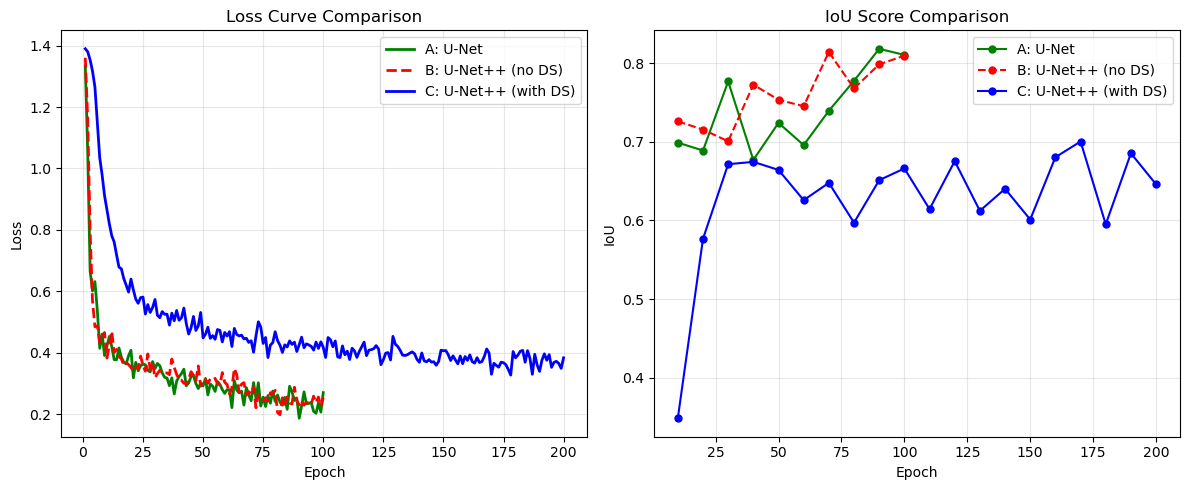

In [16]:
# ========================================
# Step 7. Loss 곡선 비교 (학습 속도)
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Loss 곡선 ──
axes[0].plot(range(1, 101), loss_a, 'g-',  label='A: U-Net',            linewidth=2)
axes[0].plot(range(1, 101), loss_b, 'r--', label='B: U-Net++ (no DS)',   linewidth=2)
axes[0].plot(range(1, 201), loss_c, 'b-',  label='C: U-Net++ (with DS)', linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── IoU 변화 ──
x_a = list(range(10, 101, 10))   # 100 에폭 → 10개
x_b = list(range(10, 101, 10))   # 100 에폭 → 10개
x_c = list(range(10, 201, 10))   # 200 에폭 → 20개

axes[1].plot(x_a, iou_a, 'g-o',  label='A: U-Net',            markersize=5)
axes[1].plot(x_b, iou_b, 'r--o', label='B: U-Net++ (no DS)',   markersize=5)
axes[1].plot(x_c, iou_c, 'b-o',  label='C: U-Net++ (with DS)', markersize=5)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU")
axes[1].set_title("IoU Score Comparison")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir + '/ablation_loss_iou.png', dpi=150)
plt.show()

/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

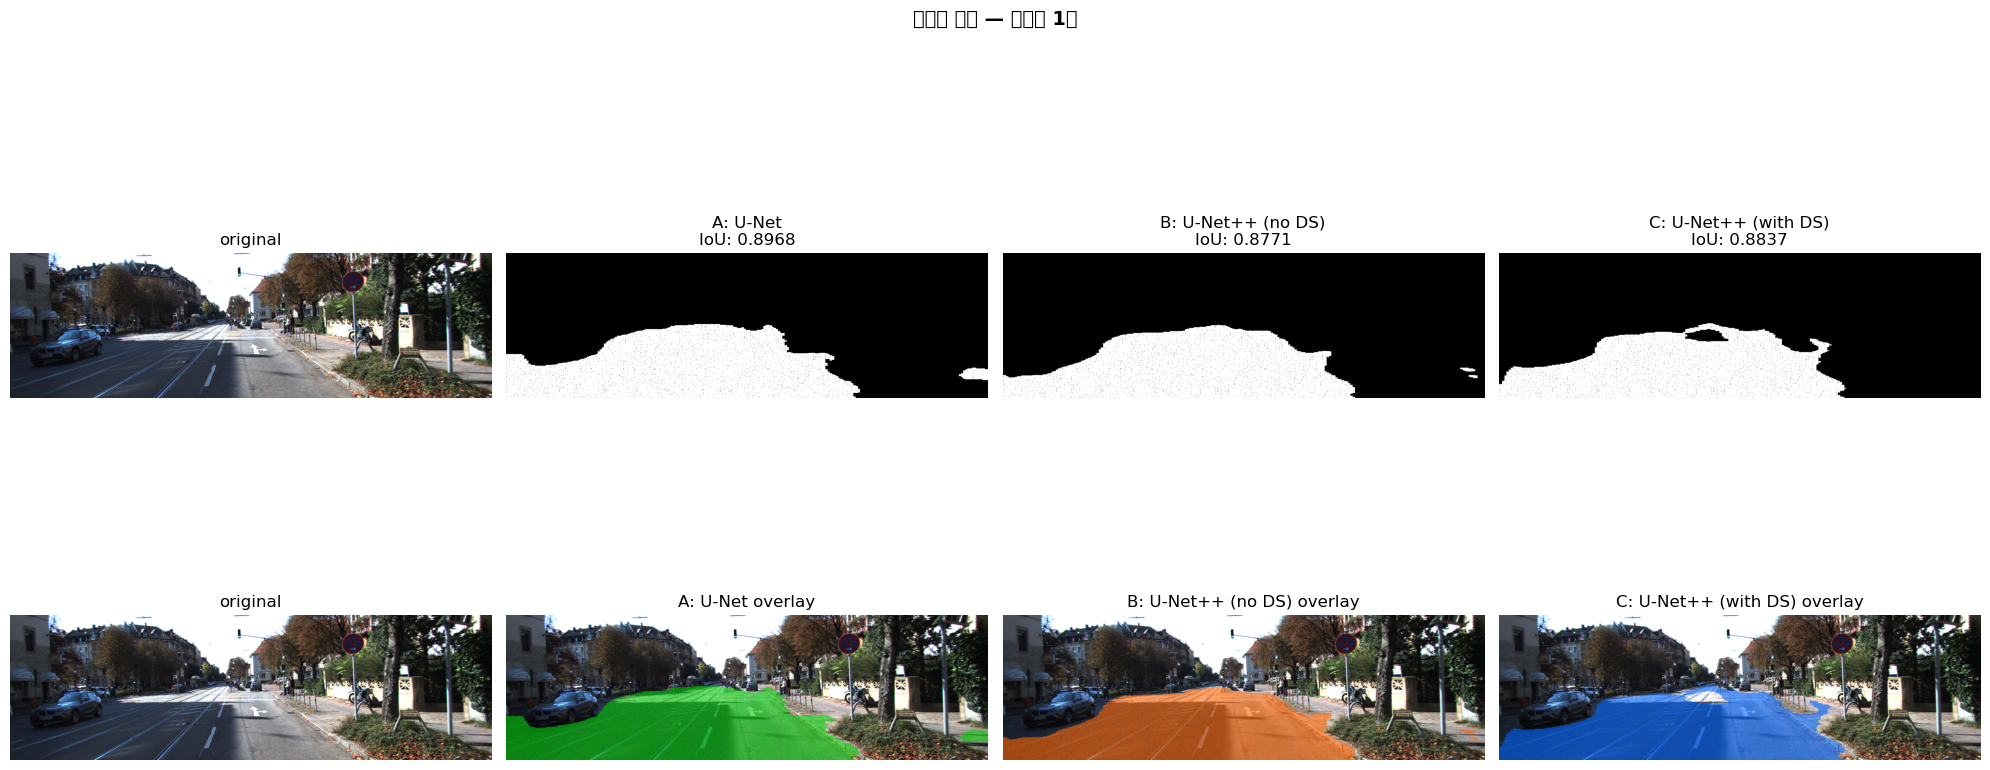


이미지 1번 Ablation Study Final Result
A: U-Net              IoU: 0.8968
B: U-Net++ (no DS)  IoU: 0.8771  (-0.0197 vs A)
C: U-Net++ (with DS)  IoU: 0.8837  (-0.0131 vs A)
DS Effect:               +0.0066 (C - B)


/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

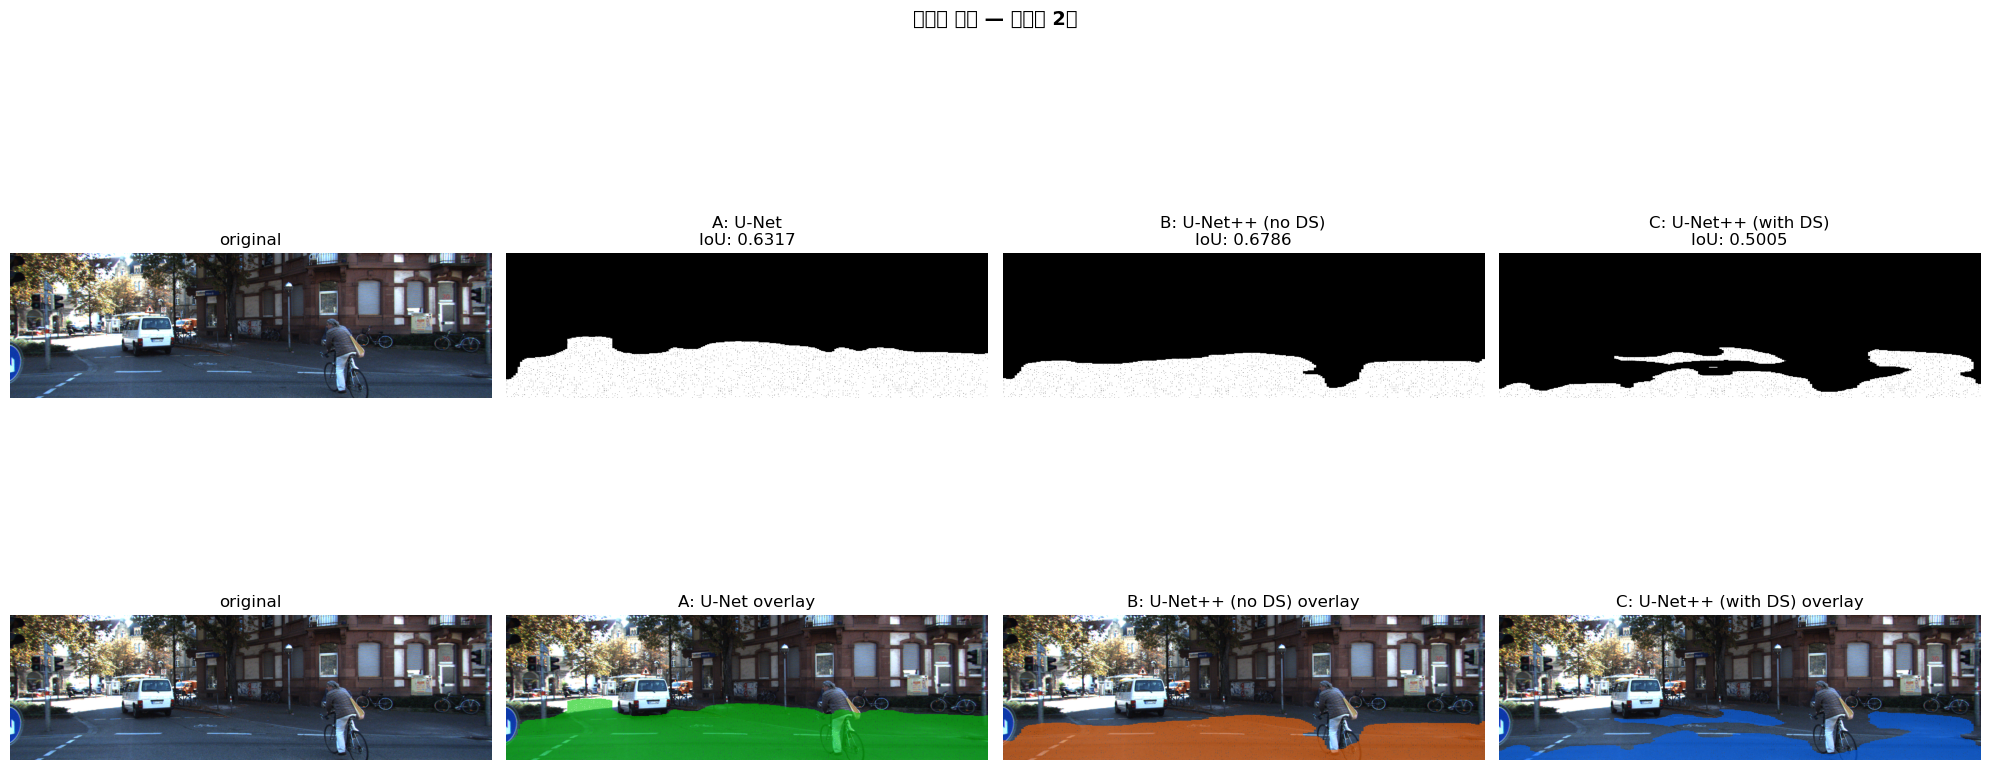


이미지 2번 Ablation Study Final Result
A: U-Net              IoU: 0.6317
B: U-Net++ (no DS)  IoU: 0.6786  (+0.0468 vs A)
C: U-Net++ (with DS)  IoU: 0.5005  (-0.1313 vs A)
DS Effect:               -0.1781 (C - B)


/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_409/434999598.py:61: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

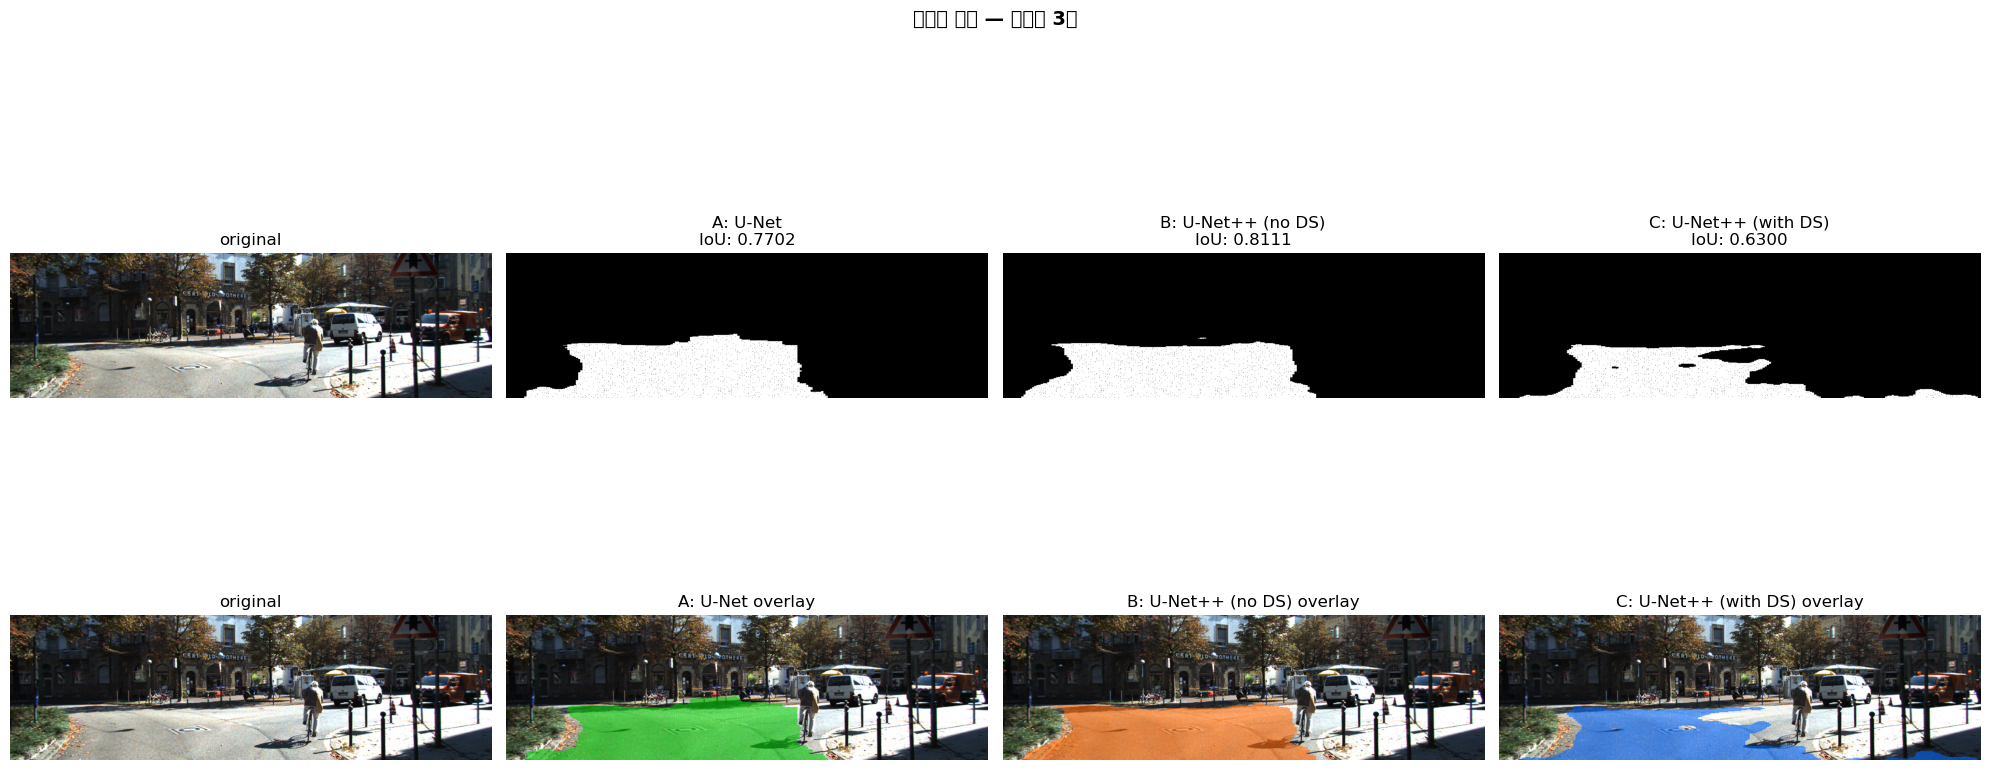


이미지 3번 Ablation Study Final Result
A: U-Net              IoU: 0.7702
B: U-Net++ (no DS)  IoU: 0.8111  (+0.0409 vs A)
C: U-Net++ (with DS)  IoU: 0.6300  (-0.1402 vs A)
DS Effect:               -0.1811 (C - B)


In [13]:
# ========================================
# Step 8. 경계선(Boundary) 정교함 비교
# ========================================
preproc = build_augmentation(is_train=False)

def get_mask(model, image_path):
    origin = imread(image_path)
    proc   = preproc(image=origin)["image"]
    tensor = torch.tensor(proc / 255.0, dtype=torch.float32
                          ).permute(2, 0, 1).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        out = model(tensor)
    mask = (out[0].squeeze().cpu().numpy() > 0.5).astype(np.uint8)
    return origin, resize(mask, origin.shape[:2], preserve_range=True).astype(np.uint8)


def compare_boundary(i=1):
    img_path = data_dir + f'/image_2/00{str(i).zfill(4)}_10.png'
    lbl_path = data_dir + f'/semantic/00{str(i).zfill(4)}_10.png'

    origin, mask_a = get_mask(model_a, img_path)
    _,      mask_b = get_mask(model_b, img_path)
    _,      mask_c = get_mask(model_c, img_path)

    # 정답 마스크
    lbl_proc = preproc(image=imread(lbl_path))["image"]
    target   = resize((lbl_proc == 7).astype(np.uint8),
                      origin.shape[:2], preserve_range=True).astype(np.uint8)

    iou_a_ = calculate_iou(target, mask_a)
    iou_b_ = calculate_iou(target, mask_b)
    iou_c_ = calculate_iou(target, mask_c)

    def overlay(img, mask, color):
        out = img.copy()
        out[mask == 1] = (out[mask == 1] * 0.4 + np.array(color) * 0.6).astype(np.uint8)
        return out

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(f"경계선 비교 — 이미지 {i}번", fontsize=14, fontweight='bold')

    # 1행: 마스크
    axes[0][0].imshow(origin);       axes[0][0].set_title("original");          axes[0][0].axis("off")
    axes[0][1].imshow(mask_a, cmap="gray")
    axes[0][1].set_title(f"A: U-Net\nIoU: {iou_a_:.4f}");                  axes[0][1].axis("off")
    axes[0][2].imshow(mask_b, cmap="gray")
    axes[0][2].set_title(f"B: U-Net++ (no DS)\nIoU: {iou_b_:.4f}");      axes[0][2].axis("off")
    axes[0][3].imshow(mask_c, cmap="gray")
    axes[0][3].set_title(f"C: U-Net++ (with DS)\nIoU: {iou_c_:.4f}");      axes[0][3].axis("off")

    # 2행: 오버레이
    axes[1][0].imshow(origin);       axes[1][0].set_title("original");          axes[1][0].axis("off")
    axes[1][1].imshow(overlay(origin, mask_a, [0, 200,   0]))
    axes[1][1].set_title("A: U-Net overlay");                               axes[1][1].axis("off")
    axes[1][2].imshow(overlay(origin, mask_b, [255, 100,  0]))
    axes[1][2].set_title("B: U-Net++ (no DS) overlay");                   axes[1][2].axis("off")
    axes[1][3].imshow(overlay(origin, mask_c, [0, 100, 255]))
    axes[1][3].set_title("C: U-Net++ (with DS) overlay");                   axes[1][3].axis("off")

    plt.tight_layout()
    plt.savefig(data_dir + f'/ablation_boundary_{i}.png', dpi=150)
    plt.show()

    print(f"\n{'='*45}")
    print(f"이미지 {i}번 Ablation Study Final Result")
    print(f"{'='*45}")
    print(f"A: U-Net              IoU: {iou_a_:.4f}")
    print(f"B: U-Net++ (no DS)  IoU: {iou_b_:.4f}  ({iou_b_-iou_a_:+.4f} vs A)")
    print(f"C: U-Net++ (with DS)  IoU: {iou_c_:.4f}  ({iou_c_-iou_a_:+.4f} vs A)")
    print(f"DS Effect:               {iou_c_-iou_b_:+.4f} (C - B)")

for i in [1, 2, 3]:
    compare_boundary(i=i)


     Ablation Study Final Result
  A: U-Net              평균 IoU: 0.7676
  B: U-Net++ (no DS)  Mean IoU: 0.8118  (+0.0443)
  C: U-Net++ (with DS) Mean IoU: 0.7529  (-0.0147)
  DS Effect (C - B):      -0.0590


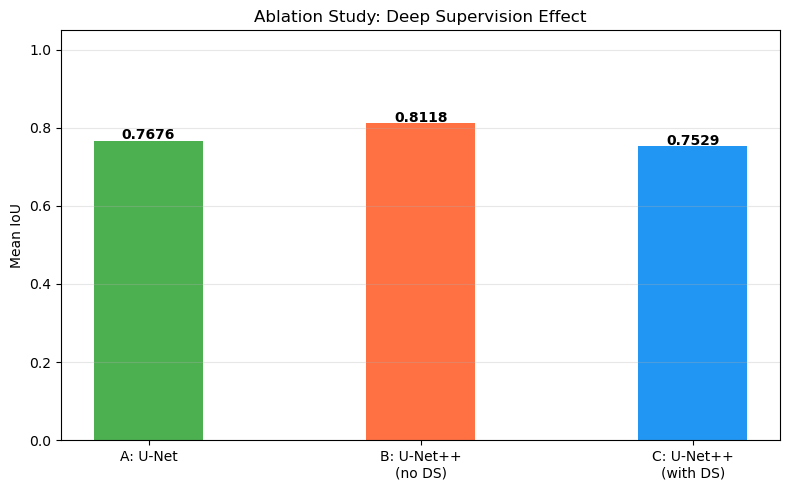

In [14]:
# ========================================
# Step 9. 전체 테스트셋 최종 정량 비교
# ========================================
def eval_all(model, n=10):
    ious = []
    for i in range(1, n+1):
        img_path = data_dir + f'/image_2/00{str(i).zfill(4)}_10.png'
        lbl_path = data_dir + f'/semantic/00{str(i).zfill(4)}_10.png'
        if not os.path.exists(img_path):
            continue
        origin, mask = get_mask(model, img_path)
        lbl_proc = preproc(image=imread(lbl_path))["image"]
        target   = resize((lbl_proc == 7).astype(np.uint8),
                          origin.shape[:2], preserve_range=True).astype(np.uint8)
        ious.append(calculate_iou(target, mask))
    return np.mean(ious)

mean_a = eval_all(model_a)
mean_b = eval_all(model_b)
mean_c = eval_all(model_c)

print(f"\n{'='*50}")
print(f"     Ablation Study Final Result")
print(f"{'='*50}")
print(f"  A: U-Net              평균 IoU: {mean_a:.4f}")
print(f"  B: U-Net++ (no DS)  Mean IoU: {mean_b:.4f}  ({mean_b-mean_a:+.4f})")
print(f"  C: U-Net++ (with DS) Mean IoU: {mean_c:.4f}  ({mean_c-mean_a:+.4f})")
print(f"{'='*50}")
print(f"  DS Effect (C - B):      {mean_c-mean_b:+.4f}")
print(f"{'='*50}")

# 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
models = ['A: U-Net', 'B: U-Net++\n(no DS)', 'C: U-Net++\n(with DS)']
ious   = [mean_a, mean_b, mean_c]
colors = ['#4CAF50', '#FF7043', '#2196F3']
bars   = ax.bar(models, ious, color=colors, width=0.4)

for bar, val in zip(bars, ious):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontweight='bold')

ax.set_ylabel("Mean IoU")
ax.set_title("Ablation Study: Deep Supervision Effect")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(data_dir + '/ablation_final.png', dpi=150)
plt.show()